In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 20.3 MB/s eta 0:00:00


Project directories ready:
  Checkpoints -> /content/drive/MyDrive/FinBERT_Project/checkpoints
  Logs        -> /content/drive/MyDrive/FinBERT_Project/logs
  Model saves -> /content/drive/MyDrive/FinBERT_Project/models/finbert_category_classifier_v1
  Reports     -> /content/drive/MyDrive/FinBERT_Project/reports
Config saved to: /content/drive/MyDrive/FinBERT_Project/experiments/finbert_category_classifier_v1/config.json
Using device: cuda
GPU: Tesla T4

Columns found: ['URL', 'Title', 'Category']
Shape: (5000, 3)

Category distribution (raw):
Category
Business      1896
Markets       1518
Politics       862
Technology     452
Health         144
Energy         127
NaN              1
Name: count, dtype: int64

Rows removed during cleaning: 317
Remaining rows: 4683

Category distribution (cleaned):
Category
Business      1766
Markets       1428
Politics       821
Technology     410
Health         137
Energy         121
Name: count, dtype: int64

Detected 6 categories: ['Business', 'Energ

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training log saved to: /content/drive/MyDrive/FinBERT_Project/logs/finbert_category_classifier_v1_training_log.json


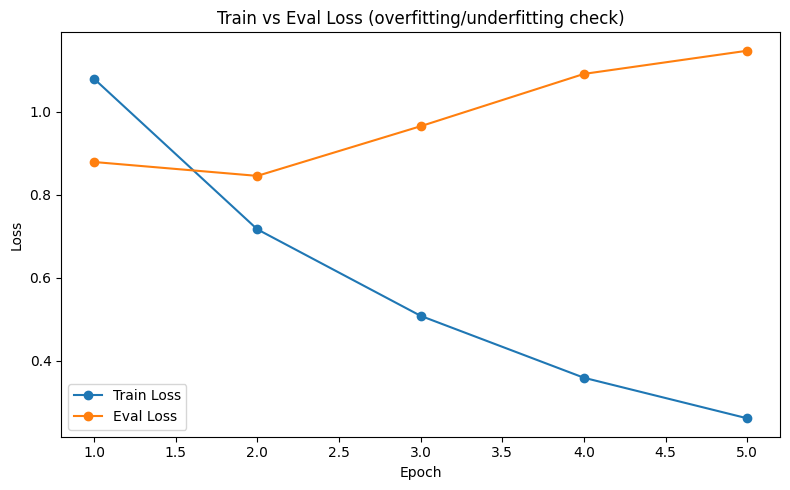

Loss curve saved to: /content/drive/MyDrive/FinBERT_Project/reports/finbert_category_classifier_v1_loss_curve.png

Final train loss: 0.2620 | Final eval loss: 1.1464
Diagnosis: Eval loss is notably higher than train loss -> model is OVERFITTING.
(Early stopping was active, so training should have already stopped near the best epoch.)



FINAL TEST METRICS
Accuracy:  0.6841
Precision: 0.6845
Recall:    0.6841
F1-score:  0.6801

Classification Report:
              precision    recall  f1-score   support

    Business       0.68      0.70      0.69       353
      Energy       0.55      0.25      0.34        24
      Health       0.64      0.57      0.60        28
     Markets       0.66      0.71      0.68       286
    Politics       0.72      0.77      0.75       164
  Technology       0.76      0.51      0.61        82

    accuracy                           0.68       937
   macro avg       0.67      0.59      0.61       937
weighted avg       0.68      0.68      0.68       937



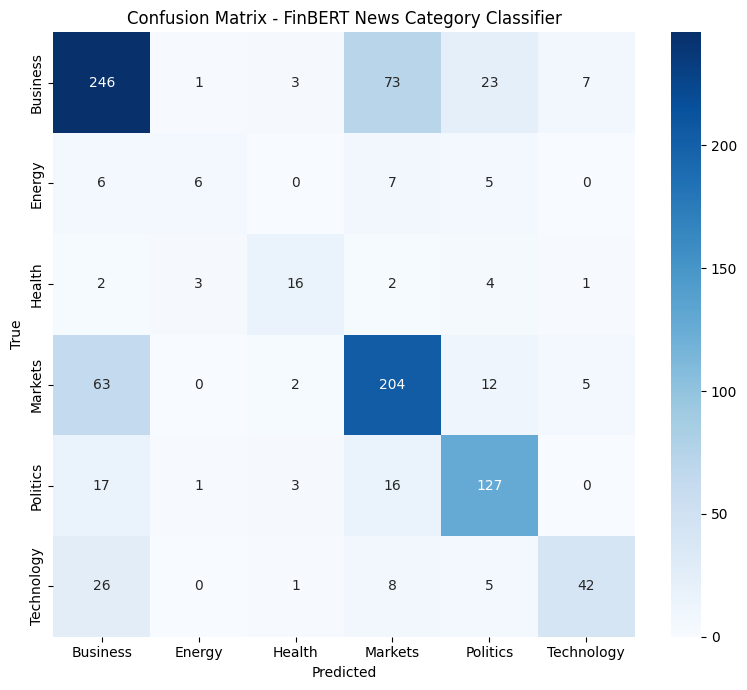

Confusion matrix saved to: /content/drive/MyDrive/FinBERT_Project/reports/finbert_category_classifier_v1_confusion_matrix.png


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model + tokenizer saved to: /content/drive/MyDrive/FinBERT_Project/models/finbert_category_classifier_v1

TRAINING SUMMARY
Rows used: 4683  |  Categories: 6 -> ['Business', 'Energy', 'Health', 'Markets', 'Politics', 'Technology']
Train/Test: 3746/937
Base model: ProsusAI/finbert
Epochs requested: 15 (early stopping patience: 3)
Final Accuracy: 0.6841 | F1: 0.6801
Checkpoints: /content/drive/MyDrive/FinBERT_Project/checkpoints
Logs: /content/drive/MyDrive/FinBERT_Project/logs/finbert_category_classifier_v1_training_log.json
Saved model: /content/drive/MyDrive/FinBERT_Project/models/finbert_category_classifier_v1


In [1]:
# =========================================================
# 0. MOUNT GOOGLE DRIVE


# =========================================================
# FinBERT News Category Classification - Fine-Tuning
# Columns used: URL (kept for reference only), Title (input text), Category (label)
# =========================================================

# !pip install -q -U transformers accelerate datasets scikit-learn torch

import os
import random
import inspect
import json
from datetime import datetime
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, set_seed, EarlyStoppingCallback,
)

# =========================================================
# 1. CONFIGURATION
# =========================================================
DATASET_PATH = "/content/drive/MyDrive/FinBERT_Project/data/News Classification Labeling - Sheet1 (4).csv"

URL_COLUMN = "URL"          # kept only for reference, not used in training
TEXT_COLUMN = "Title"       # <-- this is the text FinBERT will read
LABEL_COLUMN = "Category"   # <-- this is what FinBERT will predict

MODEL_NAME = "ProsusAI/finbert"
MAX_LENGTH = 128            # titles are short, 128 is plenty
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
NUM_EPOCHS = 15
RANDOM_SEED = 42
EARLY_STOPPING_PATIENCE = 3   # stops early ONLY if eval performance stalls for 3 epochs straight

PROJECT_ROOT = "/content/drive/MyDrive/FinBERT_Project"
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
EXPERIMENT_DIR = os.path.join(PROJECT_ROOT, "experiments")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")
REPORT_DIR = os.path.join(PROJECT_ROOT, "reports")

EXPERIMENT_NAME = "finbert_category_classifier_v1"
MODEL_SAVE_DIR = os.path.join(MODEL_DIR, EXPERIMENT_NAME)
EXPERIMENT_SAVE_DIR = os.path.join(EXPERIMENT_DIR, EXPERIMENT_NAME)

for d in [MODEL_DIR, CHECKPOINT_DIR, EXPERIMENT_DIR, LOG_DIR, REPORT_DIR, MODEL_SAVE_DIR, EXPERIMENT_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project directories ready:")
print(f"  Checkpoints -> {CHECKPOINT_DIR}")
print(f"  Logs        -> {LOG_DIR}")
print(f"  Model saves -> {MODEL_SAVE_DIR}")
print(f"  Reports     -> {REPORT_DIR}")

config = {
    "experiment_name": EXPERIMENT_NAME, "model_name": MODEL_NAME,
    "dataset_path": DATASET_PATH, "text_column": TEXT_COLUMN,
    "label_column": LABEL_COLUMN, "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS, "random_seed": RANDOM_SEED,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "created_at": datetime.now().isoformat(),
}
CONFIG_PATH = os.path.join(EXPERIMENT_SAVE_DIR, "config.json")
with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=4)
print(f"Config saved to: {CONFIG_PATH}")

# =========================================================
# 2. REPRODUCIBILITY & DEVICE
# =========================================================
def set_all_seeds(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    set_seed(seed)

set_all_seeds(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# =========================================================
# 3. LOAD DATASET
# =========================================================
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}.")

df = pd.read_csv(DATASET_PATH)

print("\nColumns found:", list(df.columns))
print(f"Shape: {df.shape}")

for col in [TEXT_COLUMN, LABEL_COLUMN]:
    if col not in df.columns:
        raise KeyError(f"'{col}' not found in dataset columns: {list(df.columns)}")

print(f"\nCategory distribution (raw):\n{df[LABEL_COLUMN].value_counts(dropna=False)}")

# =========================================================
# 4. CLEAN DATA
# =========================================================
initial_len = len(df)

df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).copy()
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str).str.strip()
df = df[df[TEXT_COLUMN].str.len() > 0].copy()

df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()
df = df[df[LABEL_COLUMN].str.len() > 0].copy()

df = df.drop_duplicates(subset=[TEXT_COLUMN, LABEL_COLUMN]).reset_index(drop=True)

cleaned_len = len(df)
print(f"\nRows removed during cleaning: {initial_len - cleaned_len}")
print(f"Remaining rows: {cleaned_len}")

if cleaned_len == 0:
    raise ValueError("No data left after cleaning.")

print(f"\nCategory distribution (cleaned):\n{df[LABEL_COLUMN].value_counts()}")

# =========================================================
# 5. ENCODE LABELS (dynamic — works for any number of categories)
# =========================================================
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df[LABEL_COLUMN])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(f"\nDetected {num_classes} categories: {class_names}")
if num_classes < 2:
    raise ValueError("Need at least 2 categories to train a classifier.")

# =========================================================
# 6. TRAIN / TEST SPLIT (80/20, stratified)
# =========================================================
train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=RANDOM_SEED, stratify=df["label_encoded"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"\nTrain: {len(train_df)} | Test: {len(test_df)}")

# =========================================================
# 7. TOKENIZER
# =========================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# =========================================================
# 8. DATASET CLASS
# =========================================================
class CategoryDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]), truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

train_dataset = CategoryDataset(train_df[TEXT_COLUMN].values, train_df["label_encoded"].values, tokenizer, MAX_LENGTH)
test_dataset = CategoryDataset(test_df[TEXT_COLUMN].values, test_df["label_encoded"].values, tokenizer, MAX_LENGTH)

# =========================================================
# 9. LOAD MODEL (classification head resized to num_classes automatically)
# =========================================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_classes, ignore_mismatched_sizes=True,
)
model.to(device)

# =========================================================
# 10. METRICS
# =========================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

# =========================================================
# 11. TRAINING ARGUMENTS (checkpoints + logging every epoch)
# =========================================================
ta_params = inspect.signature(TrainingArguments.__init__).parameters
strategy_key = "eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"

training_args_kwargs = {
    "output_dir": CHECKPOINT_DIR,
    "num_train_epochs": NUM_EPOCHS,
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    strategy_key: "epoch",
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "greater_is_better": True,
    "logging_strategy": "epoch",
    "save_total_limit": 3,
    "seed": RANDOM_SEED,
    "fp16": torch.cuda.is_available(),
    "report_to": "none",
}
if "logging_dir" in ta_params:
    training_args_kwargs["logging_dir"] = LOG_DIR

training_args = TrainingArguments(**training_args_kwargs)

# =========================================================
# 12. TRAINER (early stopping only kicks in if eval F1 stalls)
# =========================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

# =========================================================
# 13. TRAIN
# =========================================================
print("\n" + "=" * 60)
print(f"TRAINING FOR UP TO {NUM_EPOCHS} EPOCHS (may stop early if it overfits)")
print("=" * 60)
trainer.train()

TRAINING_LOG_PATH = os.path.join(LOG_DIR, f"{EXPERIMENT_NAME}_training_log.json")
with open(TRAINING_LOG_PATH, "w") as f:
    json.dump(trainer.state.log_history, f, indent=4)
print(f"Training log saved to: {TRAINING_LOG_PATH}")

# =========================================================
# 14. OVERFITTING / UNDERFITTING CHECK
# =========================================================
history = trainer.state.log_history
train_losses = [(h["epoch"], h["loss"]) for h in history if "loss" in h]
eval_losses = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]

if train_losses and eval_losses:
    plt.figure(figsize=(8, 5))
    plt.plot(*zip(*train_losses), label="Train Loss", marker="o")
    plt.plot(*zip(*eval_losses), label="Eval Loss", marker="o")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Train vs Eval Loss (overfitting/underfitting check)")
    plt.legend(); plt.tight_layout()
    LOSS_CURVE_PATH = os.path.join(REPORT_DIR, f"{EXPERIMENT_NAME}_loss_curve.png")
    plt.savefig(LOSS_CURVE_PATH, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Loss curve saved to: {LOSS_CURVE_PATH}")

    final_train_loss = train_losses[-1][1]
    final_eval_loss = eval_losses[-1][1]
    gap = final_eval_loss - final_train_loss

    print(f"\nFinal train loss: {final_train_loss:.4f} | Final eval loss: {final_eval_loss:.4f}")
    if gap > 0.3:
        print("Diagnosis: Eval loss is notably higher than train loss -> model is OVERFITTING.")
        print("(Early stopping was active, so training should have already stopped near the best epoch.)")
    elif final_train_loss > 0.6 and final_eval_loss > 0.6:
        print("Diagnosis: Both train and eval loss are still high -> model is UNDERFITTING.")
        print("Consider: more epochs, lower learning rate, or checking label quality.")
    else:
        print("Diagnosis: Train and eval loss are close and both low -> model is fitting well.")

# =========================================================
# 15. FINAL EVALUATION
# =========================================================
predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(logits, axis=-1)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print(f"\nFINAL TEST METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

report_dict = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

metrics = {"accuracy": float(accuracy), "precision": float(precision), "recall": float(recall), "f1": float(f1)}
with open(os.path.join(EXPERIMENT_SAVE_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)
with open(os.path.join(EXPERIMENT_SAVE_DIR, "classification_report.json"), "w") as f:
    json.dump(report_dict, f, indent=4)

# =========================================================
# 16. CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix - FinBERT News Category Classifier")
plt.tight_layout()
CM_PATH = os.path.join(REPORT_DIR, f"{EXPERIMENT_NAME}_confusion_matrix.png")
plt.savefig(CM_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Confusion matrix saved to: {CM_PATH}")

# =========================================================
# 17. SAVE MODEL, TOKENIZER, LABEL MAPPING
# =========================================================
trainer.save_model(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)

label_mapping = {str(idx): name for idx, name in enumerate(class_names)}
with open(os.path.join(MODEL_SAVE_DIR, "label_mapping.json"), "w") as f:
    json.dump(label_mapping, f, indent=4)

print(f"\nModel + tokenizer saved to: {MODEL_SAVE_DIR}")

# =========================================================
# 18. PREDICTION FUNCTION FOR NEW TITLES
# =========================================================
def predict_category(text: str, model_dir: str = MODEL_SAVE_DIR, max_length: int = MAX_LENGTH):
    infer_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    infer_tokenizer = AutoTokenizer.from_pretrained(model_dir)
    infer_model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(infer_device).eval()

    inputs = infer_tokenizer(str(text), truncation=True, padding="max_length",
                              max_length=max_length, return_tensors="pt").to(infer_device)
    with torch.no_grad():
        outputs = infer_model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    predicted_idx = int(np.argmax(probs))
    predicted_label = label_encoder.inverse_transform([predicted_idx])[0]
    return {
        "predicted_category": predicted_label,
        "confidence": float(probs[predicted_idx]),
        "class_probabilities": {class_names[i]: float(probs[i]) for i in range(len(class_names))},
    }

# example: predict_category("Fed raises interest rates for third time this year")

# =========================================================
# 19. FINAL SUMMARY
# =========================================================
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Rows used: {cleaned_len}  |  Categories: {num_classes} -> {class_names}")
print(f"Train/Test: {len(train_df)}/{len(test_df)}")
print(f"Base model: {MODEL_NAME}")
print(f"Epochs requested: {NUM_EPOCHS} (early stopping patience: {EARLY_STOPPING_PATIENCE})")
print(f"Final Accuracy: {accuracy:.4f} | F1: {f1:.4f}")
print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"Logs: {TRAINING_LOG_PATH}")
print(f"Saved model: {MODEL_SAVE_DIR}")
print("=" * 60)